In [1]:
import numpy as np
import pandas as pd
import time

In [2]:
CAMINHO = "C:\\Users\\Nitro\\Desktop\\Redes-Neurais\\Stellar\\star_classification.csv"

In [4]:
dataset_stellar = pd.read_csv(CAMINHO, delimiter=",")
X = dataset_stellar.loc[:, dataset_stellar.columns != 'class'].values
y = dataset_stellar["class"].values

len(dataset_stellar.columns)

18

In [5]:
np.unique(y, return_counts=True)

(array(['GALAXY', 'QSO', 'STAR'], dtype=object), array([59445, 18961, 21594]))

In [6]:
from sklearn.preprocessing import LabelEncoder
labelencoder_y = LabelEncoder()
y = labelencoder_y.fit_transform(y)

from sklearn.preprocessing import StandardScaler
scale_obj =  StandardScaler()
X = scale_obj.fit_transform(X.astype(float))

from sklearn.model_selection import train_test_split
XTrain, XTest, yTrain, yTest = train_test_split(X, y, test_size=0.15)

In [7]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver="lbfgs", max_iter=400)
start_time = time.perf_counter()
model.fit(XTrain, yTrain)
end_time = time.perf_counter()

print("Tempo de treino:", end_time - start_time)

Tempo de treino: 2.302236399962567


In [8]:
model.score(XTest, yTest)

0.9564

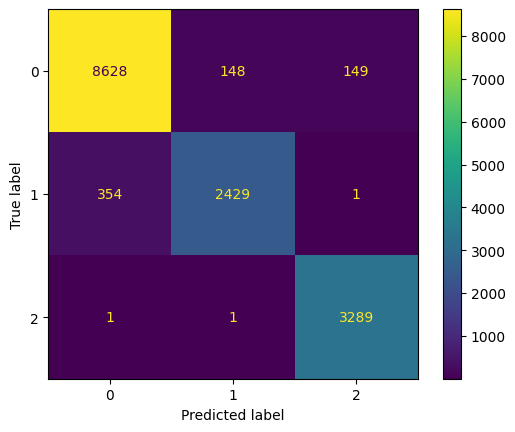

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, XTest, yTest)

Classificador com PCA (Stellar)

In [10]:
from sklearn import decomposition
pca = decomposition.PCA(n_components=10)
XTrain = pca.fit_transform(XTrain)
XTest = pca.transform(XTest) # Sem o fit para não aprender sobre o dado de teste

In [11]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver = "lbfgs", max_iter=400)
start_time = time.perf_counter()
model.fit(XTrain, yTrain)
end_time = time.perf_counter()

print("Tempo de treino:", end_time - start_time)

Tempo de treino: 0.9582541999407113


In [12]:
model.score(XTest, yTest)

0.9514666666666667

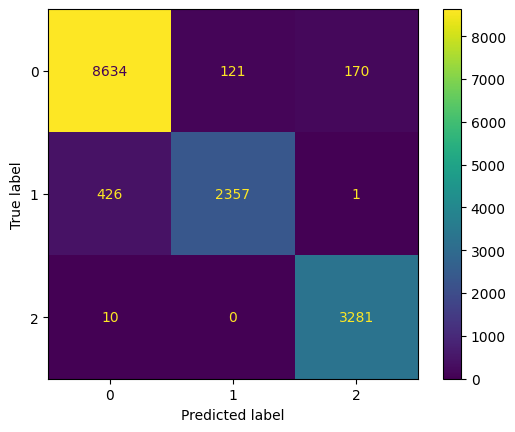

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, XTest, yTest)

Visualização PCA

In [14]:
from sklearn.decomposition import PCA
pca_viewer = PCA(n_components=2)
principal_components = pca_viewer.fit_transform(XTrain)

# Percentage of variance explained for each components
print(pca_viewer.explained_variance_ratio_)

[0.28578006 0.21262075]


In [15]:
principal_components_df = pd.DataFrame(data = principal_components, columns = ["principal component 1", "principal component 2"])

principal_components_df

,principal component 1,principal component 2
0,0.342749,-0.002178
1,-2.525107,0.419219
2,0.843759,-0.061212
3,-0.151633,0.088292
4,2.906611,-0.338448
...,...,...
84995,-0.572891,0.134694
84996,-3.123090,0.464430
84997,1.164741,-0.174890
84998,2.016585,-0.200202


In [16]:
yTrain.astype(int)
yTrain = np.where(yTrain == 0, 'GALAXY', yTrain)
yTrain = np.where(yTrain == '1', 'QSO', yTrain)
yTrain = np.where(yTrain == '2', 'STAR', yTrain)

<Figure size 640x480 with 0 Axes>

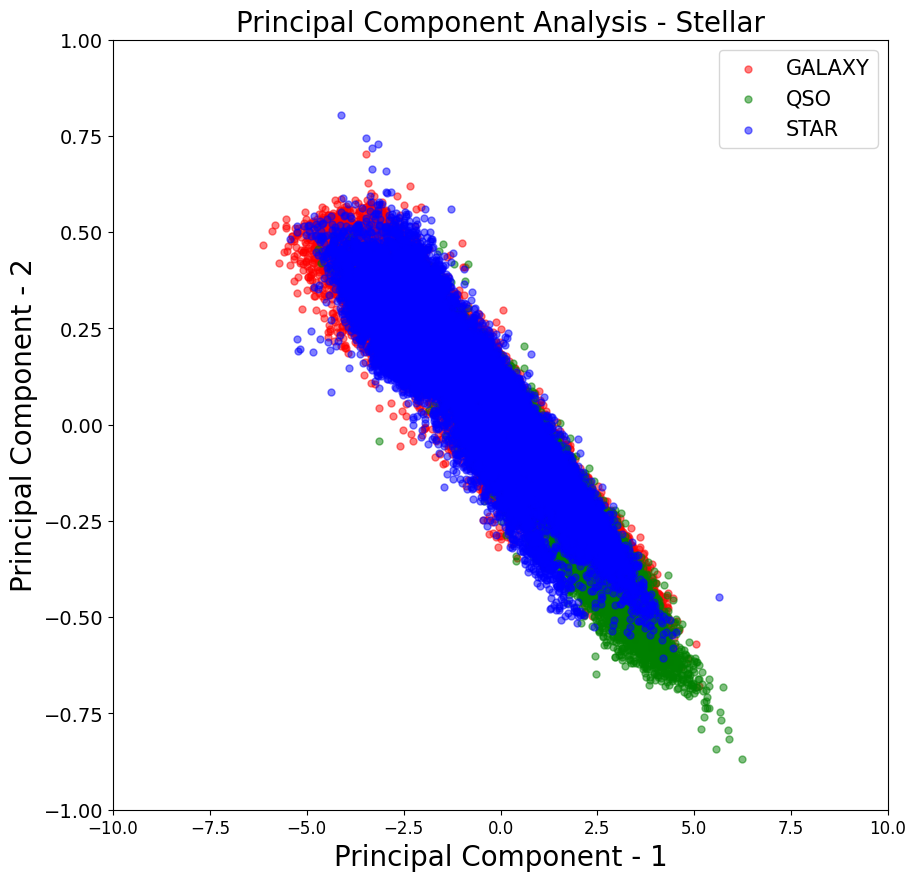

In [17]:
plt.figure()
plt.figure(figsize=(10,10))
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.xlabel('Principal Component - 1', fontsize = 20)
plt.ylabel("Principal Component - 2", fontsize = 20)
plt.xlim(-10,10)
plt.ylim(-1,1)
plt.title("Principal Component Analysis - Stellar", fontsize = 20)
targets = ["GALAXY", "QSO", "STAR"]
colors = ['r', 'g', 'b']

for target, color in zip(targets, colors):
    indicesTokeep = yTrain == target
    plt.scatter(principal_components_df.loc[indicesTokeep, 'principal component 1'],
                principal_components_df.loc[indicesTokeep, 'principal component 2'],
                c = color, s = 25, alpha=0.5)

plt.legend(targets, prop={"size" : 15})
plt.show()